In [2]:
import tensorflow as tf
import random
# libraries for data manipulation
import numpy as np
import pandas as pd

# libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# MNIST is an inbuilt dataset on tensorflow
mnist = tf.keras.datasets.mnist

# split the data into test and train sets
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# check the size of the datsets
x_train.shape, x_test.shape


((60000, 28, 28), (10000, 28, 28))

In [4]:
# We have 60000 datapoints in train dataset and 10000 datapoints in test dataset
# each denoting pixel information of a 28 * 28 image of a handwritten number

# Normalizing the data by divinding it with 255
# The reason is because the pixel values of the image can vary between 0-255
x_train, x_test = x_train / 255.0, x_test / 255.0

In [5]:
# combine the x , y train and test arrays into pandas dataframe for EDA purpose

# unwrapping the dataset such that each row contains the pixel information of
# each image and storing in the dataframe

# using the reshape function to convert a 3d array to 2d
# The number of rows remain same , the 28 * 28 matrix containing pixel info is
# unwrapped into a single row
mnist_train = pd.DataFrame(x_train.reshape(x_train.shape[0],
                                           x_train.shape[1] * x_train.shape[2]))

# repeat the same for test data
mnist_test = pd.DataFrame(x_test.reshape(x_test.shape[0],
                                           x_test.shape[1] * x_test.shape[2]))

# Create column names for dataframe to make it more readable
colnames = ['Pixel'+str(i) for i in range(1,785)]

mnist_train.columns = colnames
mnist_test.columns = colnames

# concatenate the labels into the test and train dataframe
mnist_train['label'] = y_train
mnist_test['label'] = y_test


mnist_train.head()

,Pixel1,Pixel2,Pixel3,Pixel4,Pixel5,Pixel6,Pixel7,Pixel8,Pixel9,Pixel10,...,Pixel776,Pixel777,Pixel778,Pixel779,Pixel780,Pixel781,Pixel782,Pixel783,Pixel784,label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9


In [6]:
mnist_test.head()

,Pixel1,Pixel2,Pixel3,Pixel4,Pixel5,Pixel6,Pixel7,Pixel8,Pixel9,Pixel10,...,Pixel776,Pixel777,Pixel778,Pixel779,Pixel780,Pixel781,Pixel782,Pixel783,Pixel784,label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4


In [7]:
# check if there is any NaN or missing datapoints
mnist_train.isnull().values.sum()

0

<ipython-input-8-632a92f4ea5f>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="label", data=mnist_train, palette="Set3").set(


[Text(0.5, 1.0, 'Label distribution in Training Data')]

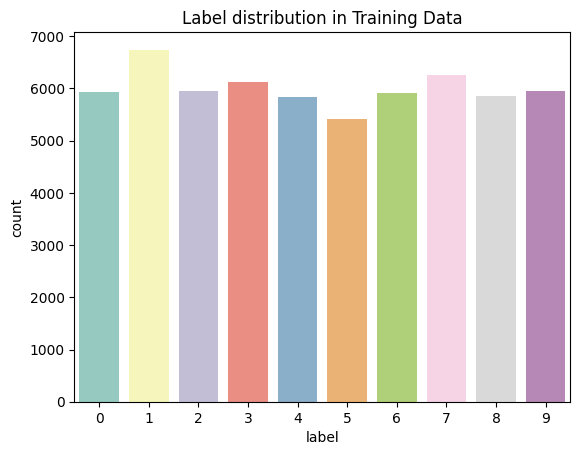

In [8]:
# check label distribution in test and train datasets
sns.countplot(x="label", data=mnist_train, palette="Set3").set(
    title="Label distribution in Training Data")

<ipython-input-9-cd5226187d3a>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="label", data=mnist_test, palette="Set2").set(


[Text(0.5, 1.0, 'Label distribution in Test Data')]

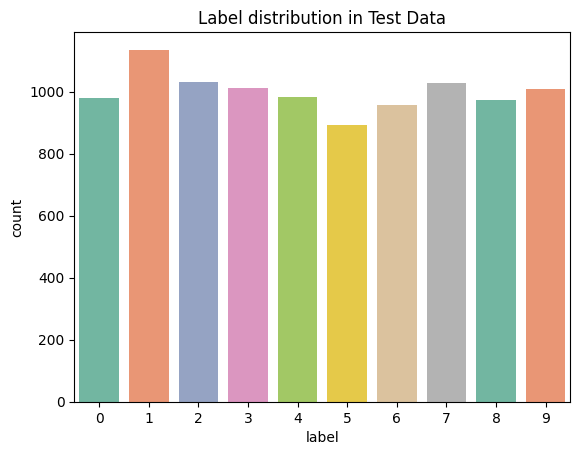

In [9]:
sns.countplot(x="label", data=mnist_test, palette="Set2").set(
    title="Label distribution in Test Data")

<ipython-input-10-2311c78994a9>:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[i].set_title(str(int(pixel_data[-1])), color= 'black', fontsize=20)


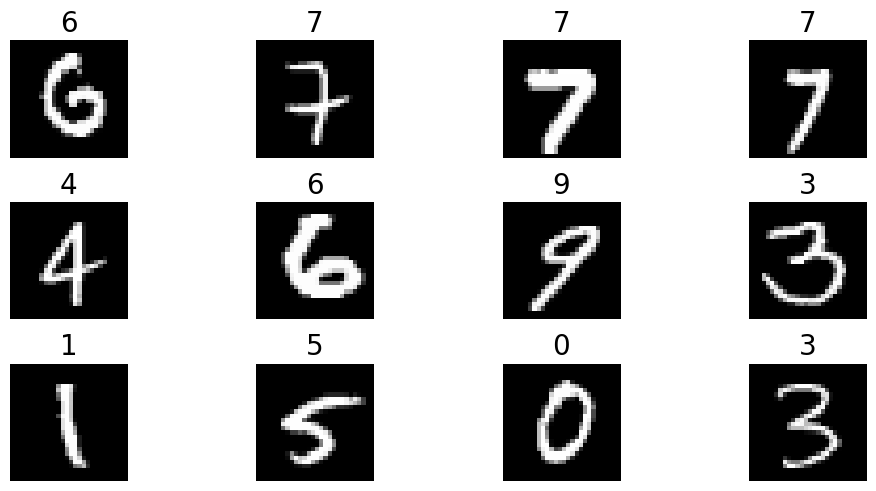

In [10]:
# visualise some of the images from train dataset
# display 4 images per row
fig, axes = plt.subplots(3,4, figsize=(10,5))
# set a tight layout for better spacing between plots
fig.tight_layout()
axes = axes.flatten()
# generate 12 random row numbers to select from mnist_train dataframe
idx = np.random.randint(0,mnist_train.shape[0],size=12)
for i in range(12):
    # get the row data
    pixel_data = mnist_train.iloc[idx[i]]
    # use imshow to build the image using pixel info
    # reshape is necessary because imshow expects a 2d array structure as input
    axes[i].imshow(np.array(pixel_data[:784]).reshape(28,28), cmap='gray')
    axes[i].axis('off')
    # add the label of the image as title
    axes[i].set_title(str(int(pixel_data[-1])), color= 'black', fontsize=20)

In [11]:
import xgboost as xb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# splitting the training data into train and validate datasets
x_train, x_val, y_train, y_val = train_test_split(x_train,
                                                  y_train,
                                                  test_size=0.1)

In [12]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, BatchNormalization, LeakyReLU, Reshape, Conv2DTranspose
from tensorflow.keras import optimizers
from tensorflow.keras import models

In [13]:
# add a channel dimension to the images
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)
x_val= np.expand_dims(x_val, axis=-1)

# one hot encoding all the labels
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)
y_val = to_categorical(y_val,10)

cnn_model = models.Sequential()

cnn_model.add(Conv2D(filters=20, kernel_size=(5, 5),
                   activation='relu', padding="same",
                   input_shape=(28,28,1)))
cnn_model.add(BatchNormalization(axis=-1))
cnn_model.add(Dropout(0.2))

cnn_model.add(Conv2D(filters=20, kernel_size=(4, 4),
                   activation='relu', padding="same"))
cnn_model.add(BatchNormalization(axis=-1))
cnn_model.add(Dropout(0.2))

cnn_model.add(Conv2D(filters=20, kernel_size=(4, 4),
                   activation='relu', padding="same"))
cnn_model.add(BatchNormalization(axis=-1))
cnn_model.add(Dropout(0.2))

cnn_model.add(Flatten())
cnn_model.add(Dense(200, activation='relu'))

cnn_model.add(Dense(10, activation='softmax'))

cnn_model_opt = optimizers.Adam(decay=1e-4)

print(cnn_model.summary())

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/optimizers/base_optimizer.py:33: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 20)          │             520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 28, 28, 20)          │              80 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 28, 28, 20)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 28, 28, 20)          │           6,420 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 28, 28, 20)          │              80 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 28, 28, 20)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 20)          │           6,420 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 28, 28, 20)          │              80 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 28, 28, 20)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 15680)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 200)                 │       3,136,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           2,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,151,810 (12.02 MB)

 Trainable params: 3,151,690 (12.02 MB)

 Non-trainable params: 120 (480.00 B)

None


In [14]:
cnn_model.compile(optimizer = cnn_model_opt , loss = "categorical_crossentropy",
                  metrics=["accuracy"])

cnn_model_fit = cnn_model.fit(x_train,
                        y_train,
                        validation_data = (x_val, y_val),
                        batch_size=128,
                        epochs=10)

cnn_test_accuracy = cnn_model.evaluate(x_test, y_test)
print("Accuracy on test data is : ", cnn_test_accuracy[1] * 100)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.9028 - loss: 0.3536 - val_accuracy: 0.8825 - val_loss: 0.3971
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9832 - loss: 0.0544 - val_accuracy: 0.9798 - val_loss: 0.0786
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9892 - loss: 0.0338 - val_accuracy: 0.9797 - val_loss: 0.0707
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9917 - loss: 0.0254 - val_accuracy: 0.9840 - val_loss: 0.0730
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9927 - loss: 0.0214 - val_accuracy: 0.9848 - val_loss: 0.0714
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9937 - loss: 0.0191 - val_accuracy: 0.9880 - val_loss: 0.0545
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9945 - loss: 0.0165 - val_accuracy: 0.9858 - val_loss: 0.0662
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9957 - loss: 0.0144 - val_accuracy:

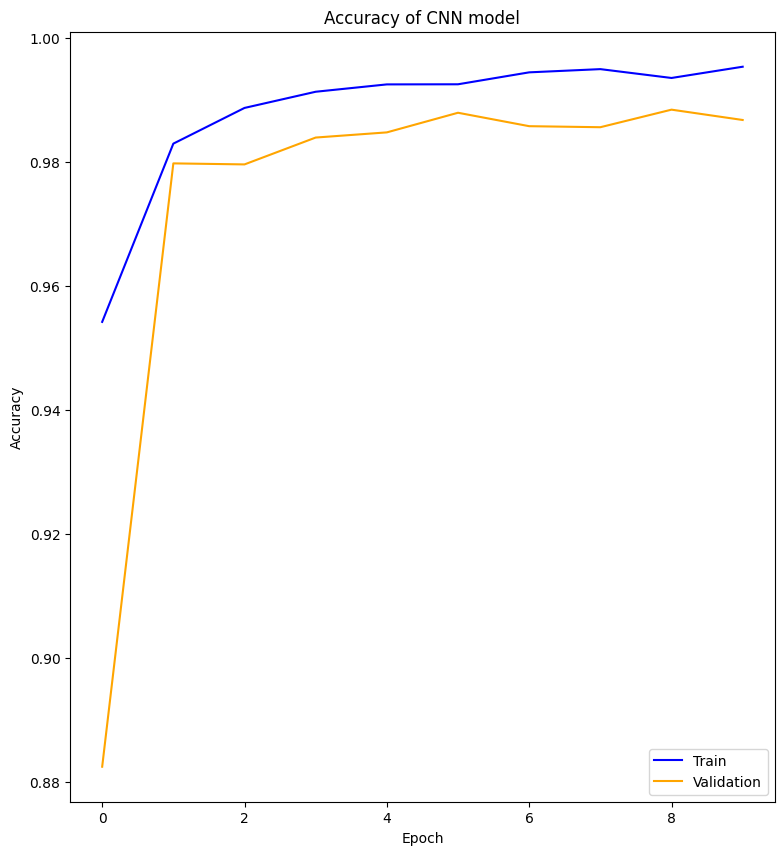

In [15]:
plt.figure(figsize=(20,10))
# plot the accuracy for the train and validation datset
plt.subplot(1,2,1)
plt.plot(cnn_model_fit.history['accuracy'], color='blue',
         label="Training accuracy")
plt.plot(cnn_model_fit.history['val_accuracy'], color='orange',
         label="Validation accuracy")
plt.title("Accuracy of CNN model")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"], loc="lower right")

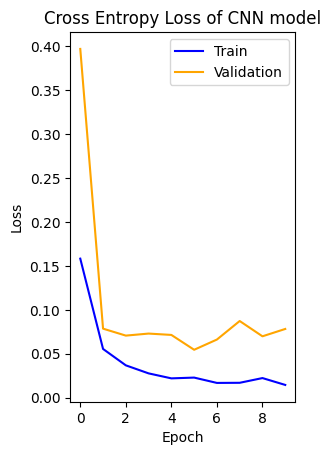

In [16]:
# plot the loss of train and validation dataset
plt.subplot(1,2,2)
plt.plot(cnn_model_fit.history['loss'], color='blue',
         label="Training loss")
plt.plot(cnn_model_fit.history['val_loss'], color='orange',
         label="Validation loss")
plt.title("Cross Entropy Loss of CNN model")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"], loc="upper right")

In [17]:
# visualising examples that are misclassified
y_test_pred = cnn_model.predict(x_test)
errors = np.absolute(y_test_pred - y_test)
errors = [np.round(np.sum(each)) for each in errors]

# check the unique error values generated
set(errors)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


{0.0, 1.0, 2.0}

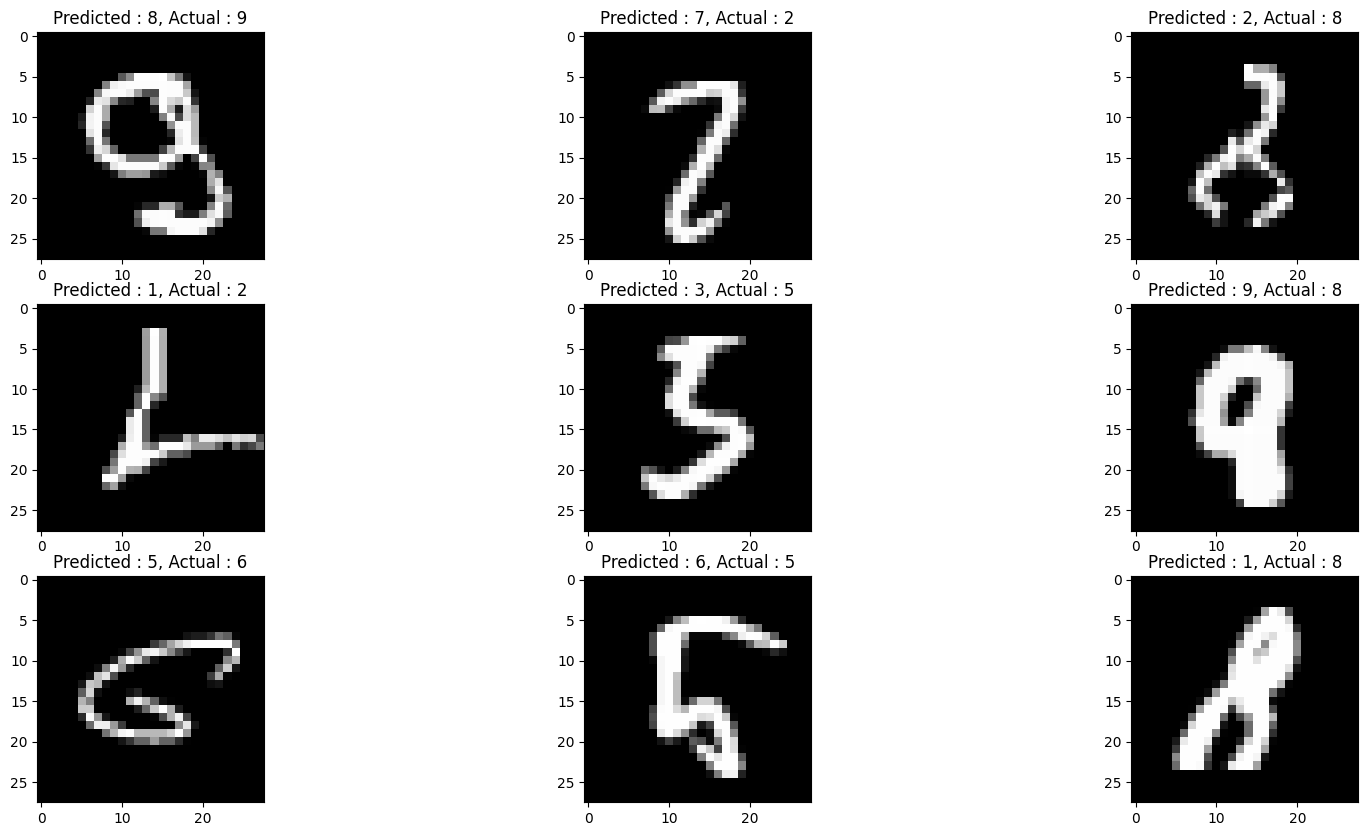

In [18]:
# since 2 is the max error difference i will fetch these indices
# and check if the index with maxvalue match in our prediction and test label
# fetching the max value because of one hot encoding
error_index = [i for i, x in enumerate(errors) if (x==2.0 and
                                                       (np.argmax(y_test_pred[i])
                                                        !=
                                                        np.argmax(y_test[i])))]

# plot the images
plt.figure(figsize=(20,10))
for i,index in enumerate(error_index[:9]):
    plt.subplot(3,3,i+1)
    plt.title("Predicted : {}, Actual : {}".format(np.argmax(y_test_pred[index]),
                                                   np.argmax(y_test[index])))
    plt.imshow(np.reshape(x_test[index],(28,28)), cmap="gray")

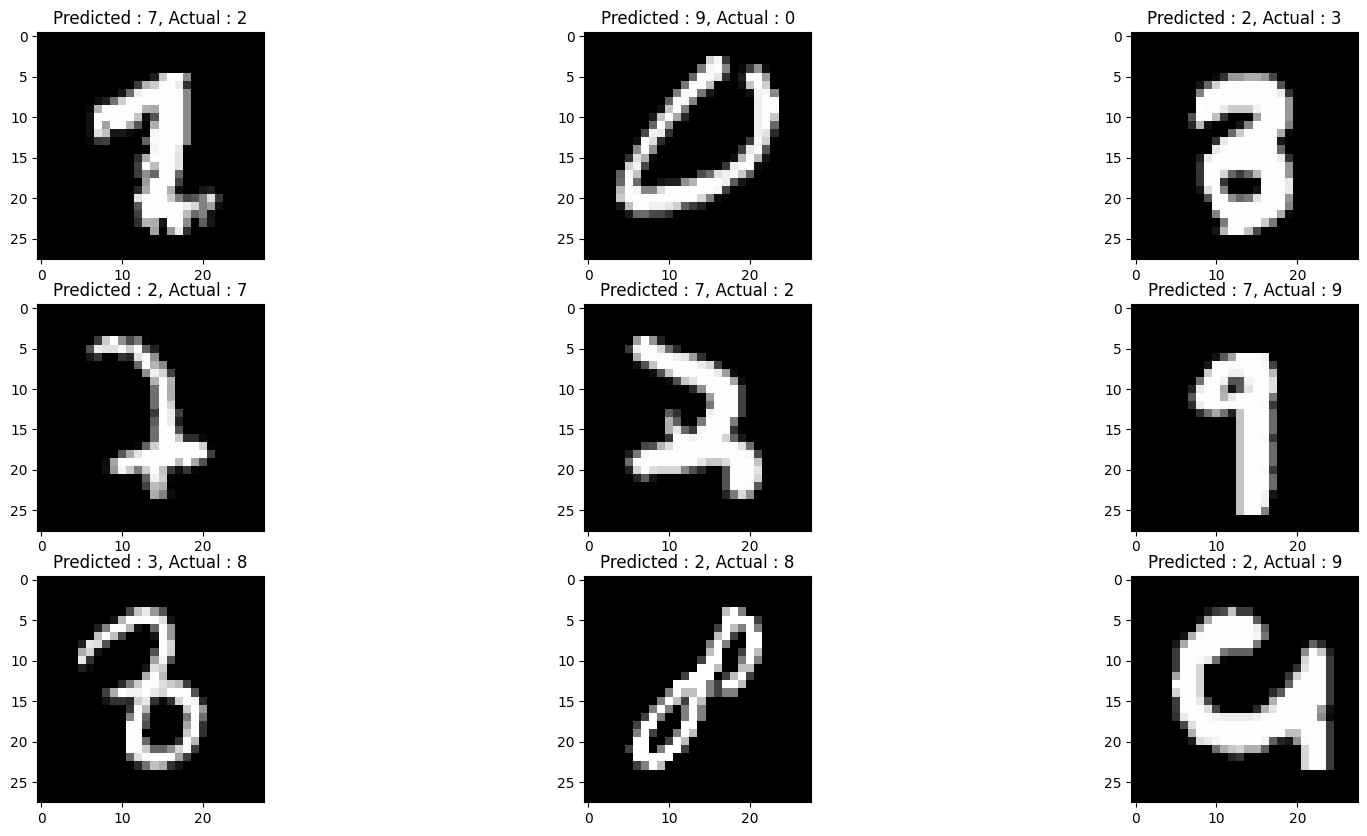

In [19]:
# repeating the same steps as above where error difference is 1.0
error_index = [i for i, x in enumerate(errors) if (x==1.0 and
                                                       (np.argmax(y_test_pred[i])
                                                        !=
                                                        np.argmax(y_test[i])))]

# plot the images
plt.figure(figsize=(20,10))
for i,index in enumerate(error_index[:9]):
    plt.subplot(3,3,i+1)
    plt.title("Predicted : {}, Actual : {}".format(np.argmax(y_test_pred[index]),
                                                   np.argmax(y_test[index])))
    plt.imshow(np.reshape(x_test[index],(28,28)), cmap="gray")

In [31]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score

# Define the FGSM attack
def FGSM(model, image, label, eps):
    image = tf.cast(image, tf.float32)  # Cast image to float32 for gradient calculation
    with tf.GradientTape() as tape:
        tape.watch(image)
        pred = model(image)
        loss = tf.keras.losses.CategoricalCrossentropy()(label, pred)
    gradient = tape.gradient(loss, image)
    signed_grad = tf.sign(gradient)
    adversary = image + signed_grad * eps
    return adversary

# Define the number of test samples to perturb
eps = 0.1  # Epsilon value for the attack
num_samples = 100  # Number of test samples to apply the attack

# Select a subset of the test data
x_test_subset = x_test[:num_samples]  # Shape: (num_samples, 28, 28, 1)
y_test_subset = y_test[:num_samples]  # Shape: (num_samples, 10)

# Ensure images are reshaped correctly
x_test_subset = np.expand_dims(x_test_subset, axis=-1)  # Shape: (num_samples, 28, 28, 1)
y_test_subset = np.expand_dims(y_test_subset, axis=-1)  # Shape: (num_samples, 10)

# Apply FGSM attack to generate adversarial examples
perturbed_images = []
for i in range(num_samples):
    image = x_test_subset[i:i+1]  # Get single image with shape (1, 28, 28, 1)
    label = y_test_subset[i:i+1]  # Get label with shape (1, 10)
    perturbed_image = FGSM(cnn_model, image, label, eps)
    perturbed_images.append(perturbed_image)  # Collect perturbed images

# Convert list to numpy array
perturbed_images = np.squeeze(np.array(perturbed_images))  # Shape: (num_samples, 28, 28, 1)

# Ensure perturbed images have the correct shape for the model (batch_size, 28, 28, 1)
perturbed_images = np.reshape(perturbed_images, (-1, 28, 28, 1))

# Make predictions on the perturbed images
predictions = cnn_model.predict(perturbed_images)  # Predictions for the adversarial images
predicted_labels = np.argmax(predictions, axis=1)  # Predicted labels
actual_labels = np.argmax(y_test_subset, axis=1)  # Actual labels

# Calculate accuracy on the perturbed images
accuracy = accuracy_score(actual_labels, predicted_labels) * 100
print(f"Accuracy on perturbed images: {accuracy:.2f}%")



4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
Accuracy on perturbed images: 61.00%


In [34]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score

# Define the FGSM attack function
def FGSM(model, image, label, eps):
    image = tf.cast(image, tf.float32)  # Cast image to float32 for gradient calculation
    with tf.GradientTape() as tape:
        tape.watch(image)
        pred = model(image)
        loss = tf.keras.losses.CategoricalCrossentropy()(label, pred)
    gradient = tape.gradient(loss, image)
    signed_grad = tf.sign(gradient)
    adversary = image + signed_grad * eps
    return adversary

# Define the number of test samples to perturb
eps = 0.1  # Epsilon value for the attack
num_samples = 100  # Number of test samples to apply the attack

# Select a subset of the test data
x_test_subset = x_test[:num_samples]  # Shape: (num_samples, 28, 28, 1)
y_test_subset = y_test[:num_samples]  # Shape: (num_samples, 10)

# Ensure images are reshaped correctly
x_test_subset = np.expand_dims(x_test_subset, axis=-1)  # Shape: (num_samples, 28, 28, 1)
y_test_subset = np.expand_dims(y_test_subset, axis=-1)  # Shape: (num_samples, 10)

# Apply FGSM attack to generate adversarial examples
perturbed_images = []
for i in range(num_samples):
    image = x_test_subset[i:i+1]  # Get single image with shape (1, 28, 28, 1)
    label = y_test_subset[i:i+1]  # Get label with shape (1, 10)
    perturbed_image = FGSM(cnn_model, image, label, eps)
    perturbed_images.append(perturbed_image)  # Collect perturbed images

# Convert list to numpy array (with correct shape)
perturbed_images = np.array(perturbed_images)  # Shape: (num_samples, 28, 28, 1)

# Ensure perturbed images have the correct shape for the model (batch_size, 28, 28, 1)
perturbed_images = np.reshape(perturbed_images, (-1, 28, 28, 1))

# Ensure labels are in the correct shape for training
y_test_subset = np.squeeze(y_test_subset, axis=-1)  # Shape: (num_samples, 10)

# Print shapes to check correctness
print("Shape of perturbed_images:", perturbed_images.shape)
print("Shape of y_test_subset:", y_test_subset.shape)

# Train the model on the perturbed images for 10 epochs and show accuracy for each epoch
history = cnn_model.fit(
    perturbed_images,
    y_test_subset,
    epochs=10,
    batch_size=32,
    verbose=1,  # Show progress bar and accuracy for each epoch
)

# Output accuracy for each epoch
for epoch in range(10):
    print(f"Epoch {epoch+1}/{10}")
    print(f"Training Accuracy: {history.history['accuracy'][epoch]:.4f}")
    print(f"Training Loss: {history.history['loss'][epoch]:.4f}")

# Evaluate the model on the perturbed images after training
predictions_perturbed = cnn_model.predict(perturbed_images)
predicted_labels_perturbed = np.argmax(predictions_perturbed, axis=1)
actual_labels_perturbed = np.argmax(y_test_subset, axis=1)

# Calculate accuracy on the perturbed images after training
accuracy_perturbed = accuracy_score(actual_labels_perturbed, predicted_labels_perturbed) * 100
print(f"Accuracy on perturbed images after 10 epochs of training: {accuracy_perturbed:.2f}%")

# Evaluate the model on the original test set
predictions_original = cnn_model.predict(x_test)  # Evaluate on the original x_test
predicted_labels_original = np.argmax(predictions_original, axis=1)
actual_labels_original = np.argmax(y_test, axis=1)

# Calculate accuracy on the original test set after training on perturbed images
accuracy_original = accuracy_score(actual_labels_original, predicted_labels_original) * 100
print(f"Accuracy on original test images after training on perturbed images: {accuracy_original:.2f}%")


Shape of perturbed_images: (100, 28, 28, 1)
Shape of y_test_subset: (100, 10)
Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.6697 - loss: 2.9100
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9785 - loss: 0.0985
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9475 - loss: 0.1194 
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9693 - loss: 0.0514 
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0035 
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9960 - loss: 0.0139 
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9785 - loss: 0.1081 
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9448 - loss: 0.2163 
Epoch 9/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0112 
Epoch 10/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0020 
Epoch 1/10
Training Accuracy: 0.6900
Training Loss: 2.6154
Epoch 2/10
Training Accuracy: 0.980